In [1]:
import sys
!{sys.executable} -m pip install datasets
!{sys.executable} -m pip install scikit-learn
!{sys.executable} -m pip install seaborn matplotlib

You should consider upgrading via the 'c:\Users\14981\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


You should consider upgrading via the 'c:\Users\14981\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


You should consider upgrading via the 'c:\Users\14981\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [2]:

from datasets import load_dataset

dataset = load_dataset("imdb")

print(dataset)
print(dataset["train"][0])

c:\Users\14981\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})
{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and

In [3]:
train_texts = dataset["train"]["text"]
train_labels = dataset["train"]["label"]

test_texts = dataset["test"]["text"]
test_labels = dataset["test"]["label"]

print(len(train_texts), len(test_texts))

25000 25000


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=20000,
    stop_words="english"
)

X_train = vectorizer.fit_transform(train_texts)
X_test = vectorizer.transform(test_texts)

print(X_train.shape)

(25000, 20000)


In [5]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, train_labels)

predictions = model.predict(X_test)

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

print("Accuracy:", accuracy_score(test_labels, predictions))
print("Macro F1:", f1_score(test_labels, predictions, average="macro"))
print(confusion_matrix(test_labels, predictions))

Accuracy: 0.87996
Macro F1: 0.87995987995988
[[10987  1513]
 [ 1488 11012]]


In [6]:
review_lengths = [len(t.split()) for t in train_texts]

print("Average review length:", sum(review_lengths)/len(review_lengths))
print("Max length:", max(review_lengths))
print("Min length:", min(review_lengths))

Average review length: 233.7872
Max length: 2470
Min length: 10


In [7]:
for i in range(len(predictions)):
    if predictions[i] != test_labels[i]:
        print("TRUE:", test_labels[i])
        print("PRED:", predictions[i])
        print(test_texts[i][:300])
        print("-----")
        break

TRUE: 0
PRED: 1
First off let me say, If you haven't enjoyed a Van Damme movie since bloodsport, you probably will not like this movie. Most of these movies may not have the best plots or best actors but I enjoy these kinds of movies for what they are. This movie is much better than any of the movies the other acti
-----


In [8]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, train_labels)

nb_pred = nb_model.predict(X_test)

print("NB Accuracy:", accuracy_score(test_labels, nb_pred))
print("NB Macro F1:", f1_score(test_labels, nb_pred, average="macro"))

NB Accuracy: 0.83192
NB Macro F1: 0.8315734574031814


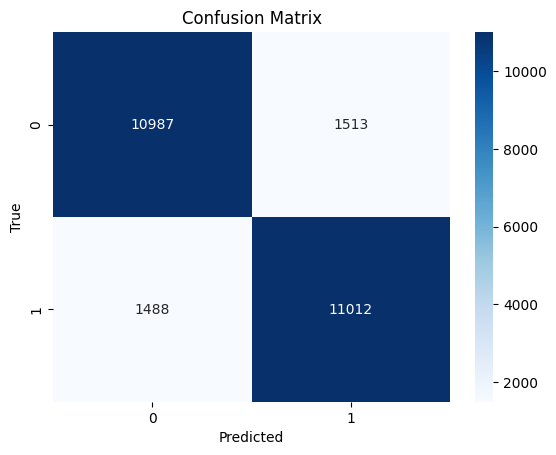

<Figure size 640x480 with 0 Axes>

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(test_labels, predictions)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()
plt.savefig("../figures/confusion_matrix.png", dpi=300)

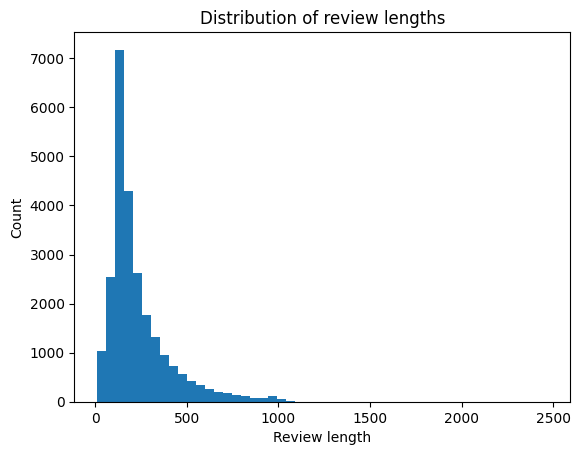

<Figure size 640x480 with 0 Axes>

In [10]:
import matplotlib.pyplot as plt

plt.hist(review_lengths, bins=50)
plt.xlabel("Review length")
plt.ylabel("Count")
plt.title("Distribution of review lengths")
plt.show()
plt.savefig("../figures/Distribution_of_review_lengths.png", dpi=300)